## Symulator tomografu komputerowego

#### Skład grupy

- Paulina Serdeczna 160191
- Oliwia Tarent 160262

#### Zastosowany model tomografu

W projekcie zostosowany został model stożkowy tomografu. Ruch emitera i detektorów został zamodelowany z użyciem przedstawionej poniżej funkcji kąta.

<br>

<img src="./notebook_img/model.png" height="400px"/>
<img src="./notebook_img/funkcja.png" height="400px" />

#### Zastosowany język programowania oraz dodatkowe biblioteki

Do realizacji projektu użyty został język Python. Projekt powstał w postaci interaktywnego notebook'a.

Biblioteki użyte w projekcie:
1. skimage - wczytywanie obrazu wejściowego, algorytm Bresenhama, funkcje pomocnicze do tworzenia pliku DICOM, obliczanie błędu średniokwadratowego
2. matplotlib - wyświetlanie obrazów
3. numpy - wykonywanie obliczeń
4. ipywidget - możliwość zmiany parametrów programu w czasie rzeczywistym
5. pydicom - tworzenie pliku DICOM

In [19]:
from skimage import io, color, img_as_float
from skimage.draw import line_nd
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider

from pydicom.dataset import Dataset, FileDataset
import pydicom._storage_sopclass_uids
from skimage import img_as_uint
from skimage.exposure import rescale_intensity

from skimage.metrics import mean_squared_error

#### Transformata Radona (tworzenie sinogramu)

In [2]:
def sample_line(img, x0, y0, x1, y1):
    h, w = img.shape
    
    start = (int(round(y0)), int(round(x0)))
    end   = (int(round(y1)), int(round(x1)))

    rr, cc = line_nd(start, end)
    
    values = []
    
    for r, c in zip(rr, cc):
        if 0 <= r < h and 0 <= c < w:
            values.append(img[r, c])
    
    return np.sum(values)

In [3]:
def radon_transformation(img, alpha, n, phi, iterations=None):
    h, w = img.shape
    cx, cy = w // 2, h // 2
    r = np.sqrt(cx**2 + cy**2)

    angles = np.deg2rad(np.arange(0, 360, alpha))

    sinogram = []

    if iterations is None:
        iterations = len(angles)
        
    iterations = min(iterations, len(angles))

    for iteration in range(iterations):
        a = angles[iteration]
        projections = []

        xE = cx + r * np.cos(a)
        yE = cy - r * np.sin(a)

        for i in range(n):
            if i == 0:
                xD = cx + r * np.cos(a + np.pi - (phi / 2))
                yD = cy - r * np.sin(a + np.pi - (phi / 2))
            else:
                xD = cx + r * np.cos(a + np.pi - (phi / 2) + i * (phi / (n - 1)))
                yD = cy - r * np.sin(a + np.pi - (phi / 2) + i * (phi / (n - 1)))

            val = sample_line(img, xE, yE, xD, yD)
            projections.append(val)

        sinogram.append(projections)
    
    return np.array(sinogram)

#### Filtrowanie sinogramu

In [4]:
def filter(sinogram):
    filtered_sinogram = []
    kernel = []

    for k in range(-10, 11):
        if k == 0:
            kernel.append(1)
        elif k % 2 == 0:
            kernel.append(0)
        else:
            kernel.append((-4 / (np.pi**2)) / k**2)

    # kernel = kernel[0:len(kernel) // 2]

    for i in range(len(sinogram)):
        filtered_sinogram.append(np.convolve(sinogram[i, :], kernel, mode='same'))
    
    return np.array(filtered_sinogram)

#### Odwrotna transformata Radona (rekonstrukcja obrazu)

In [5]:
def get_line(img, x0, y0, x1, y1):
    h, w = img.shape
    
    start = (int(round(y0)), int(round(x0)))
    end   = (int(round(y1)), int(round(x1)))

    rr, cc = line_nd(start, end)

    points = []
    
    for r, c in zip(rr, cc):
        if 0 <= r < h and 0 <= c < w:
            points.append((c, r))

    return points

In [6]:
def inverse_radon_transformation(img, sinogram, alpha, n, phi, iterations=None):
    h, w = img.shape
    cx, cy = w // 2, h // 2
    r = np.sqrt(cx**2 + cy**2)

    reconstructed_img = np.zeros((h, w))
    
    angles = np.deg2rad(np.arange(0, 360, alpha))
    
    if iterations is None:
        iterations = len(angles)
        
    iterations = min(iterations, len(angles))

    for iteration in range(iterations):
        a = angles[iteration]
        
        xE = cx + r * np.cos(a)
        yE = cy - r * np.sin(a)

        for i in range(n):
            if i == 0:
                xD = cx + r * np.cos(a + np.pi - (phi / 2))
                yD = cy - r * np.sin(a + np.pi - (phi / 2))
            else:
                xD = cx + r * np.cos(a + np.pi - (phi / 2) + i * (phi / (n - 1)))
                yD = cy - r * np.sin(a + np.pi - (phi / 2) + i * (phi / (n - 1)))

            line = get_line(img, xE, yE, xD, yD)

            val = sinogram[iteration, i]

            for x, y in line:
                if 0 <= x < w and 0 <= y < h:
                    reconstructed_img[y, x] += val

    img_min = np.min(reconstructed_img)
    img_max = np.max(reconstructed_img)

    reconstructed_img = (reconstructed_img - img_min) / (img_max - img_min)

    return reconstructed_img

#### Zapis pliku DICOM

In [7]:
def convert_image_to_uint16(img):
    return img_as_uint(rescale_intensity(img, out_range=(0.0, 1.0)))

def save_as_dicom(file_name, img, patient_data):
    img_converted = convert_image_to_uint16(img)
    
    meta = Dataset()
    meta.MediaStorageSOPClassUID = pydicom._storage_sopclass_uids.CTImageStorage
    meta.MediaStorageSOPInstanceUID = pydicom.uid.generate_uid()
    meta.TransferSyntaxUID = pydicom.uid.ExplicitVRLittleEndian  

    ds = FileDataset(None, {}, preamble=b"\0" * 128)
    ds.file_meta = meta

    ds.is_little_endian = True
    ds.is_implicit_VR = False

    ds.SOPClassUID = pydicom._storage_sopclass_uids.CTImageStorage
    ds.SOPInstanceUID = meta.MediaStorageSOPInstanceUID
    
    ds.PatientName = patient_data["PatientName"]
    ds.PatientID = patient_data["PatientID"]
    ds.ImageComments = patient_data["ImageComments"]
    
    ds.Modality = "CT"
    ds.SeriesInstanceUID = pydicom.uid.generate_uid()
    ds.StudyInstanceUID = pydicom.uid.generate_uid()
    ds.FrameOfReferenceUID = pydicom.uid.generate_uid()

    ds.BitsStored = 16
    ds.BitsAllocated = 16
    ds.SamplesPerPixel = 1
    ds.HighBit = 15

    ds.ImagesInAcquisition = 1
    ds.InstanceNumber = 1

    ds.Rows, ds.Columns = img_converted.shape

    ds.ImageType = r"ORIGINAL\PRIMARY\AXIAL"

    ds.PhotometricInterpretation = "MONOCHROME2"
    ds.PixelRepresentation = 0

    pydicom.dataset.validate_file_meta(ds.file_meta, enforce_standard=True)

    ds.PixelData = img_converted.tobytes()

    ds.save_as(file_name, write_like_original=False)

#### Wyświetlanie wyników

In [32]:
def ct(filename, alpha, n, phi_deg, progress=100, useFilter=True):
    try:
        img = io.imread(f'img/{filename}')
        img = img_as_float(img)
        
        if len(img.shape) == 3:
            img = color.rgb2gray(img)

        phi_rad = np.deg2rad(phi_deg)

        total_iterations = len(np.arange(0, 360, alpha))
        current_iterations = int(total_iterations * (progress / 100))

        sinogram = radon_transformation(img, alpha, n, phi_rad, current_iterations)

        if useFilter:
            sinogram = filter(sinogram)

        global reconstructed_img 
        reconstructed_img = inverse_radon_transformation(img, sinogram, alpha, n, phi_rad, current_iterations)

        if np.max(reconstructed_img) > 0:
            reconstructed_img = reconstructed_img / np.max(reconstructed_img)

        fig, axes = plt.subplots(
            1, 3,
            figsize=(20, 6),
            gridspec_kw={'width_ratios': [1, 1.3, 1]}
        )
        
        axes[0].imshow(img, cmap='gray')
        axes[0].set_title("Obraz wejściowy")
        axes[0].axis('off')
        
        axes[1].imshow(sinogram, cmap='gray')
        axes[1].set_title("Sinogram")
        
        axes[2].imshow(reconstructed_img, cmap='gray', aspect='equal')
        axes[2].set_title(f"Zrekonstruowany obraz")
        axes[2].axis('off')

        dicom_filename = filename.split('.')[0]
        save_as_dicom(f'./dcm/{dicom_filename}.dcm', reconstructed_img, {'PatientName': 'Scout', 'PatientID': '45', 'ImageComments': 'test'})

        error = mean_squared_error(img, reconstructed_img)
        print(f"Błąd średniokwadratowy: {error}")
        
        plt.show()
    except FileNotFoundError:
        print('Podaj poprawną nazwę pliku!')

#### Przykład działania programu



In [33]:
interact(
    ct, 
    filename='Shepp_logan.jpg',
    alpha=IntSlider(min=1, max=10, step=1, value=4, description='Krok (deg):'),
    n=IntSlider(min=90, max=360, step=10, value=180, description='Detektory:'),
    phi_deg=IntSlider(min=45, max=270, step=15, value=90, description='Rozpiętość:'),
    progress=IntSlider(min=2, max=100, step=2, value=100, description='Postęp %:'),
    useFilter=True
)

interactive(children=(Text(value='Shepp_logan.jpg', description='filename'), IntSlider(value=4, description='K…

<function __main__.ct(filename, alpha, n, phi_deg, progress=100, useFilter=True)>

Błąd średniokwadratowy: 0.03455160736502857


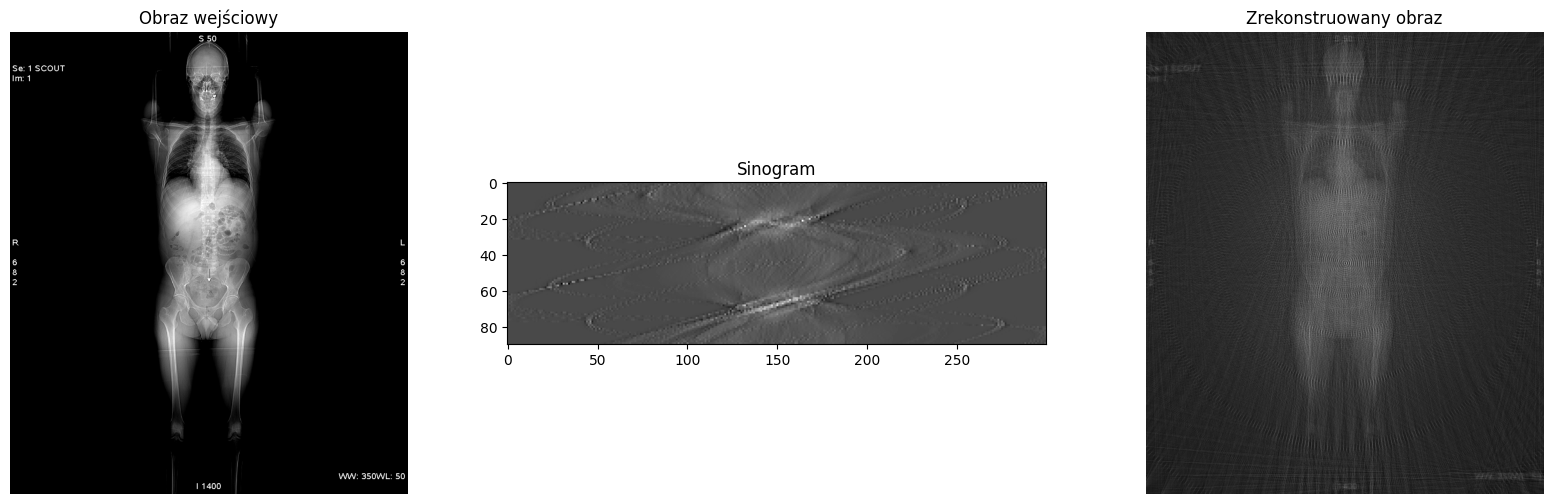

Błąd średniokwadratowy: 0.10403515623620153


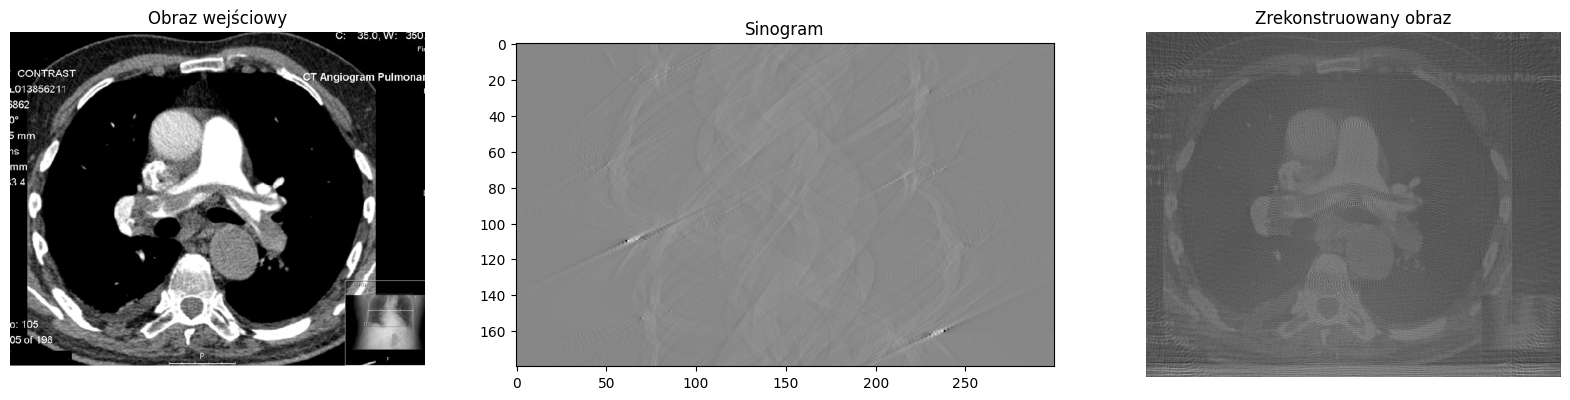

In [34]:
img = 'CT_ScoutView.jpg'
ct(img, 4, 300, 225, 100, True)

img = 'SADDLE_PE.JPG'
ct(img, 2, 300, 270, 100, True)